# 핵심 결과 — DepMap Mutation 기반 유전체 불안정성 예측

DepMap mutation만으로 WGD/CIN/LOH를 예측하고 최소 biomarker panel을 찾는
프로젝트의 핵심 결과만 간결하게 정리한 노트북이다. 전체 파이프라인은
`01_full_pipeline.ipynb`, 전체 문서는 https://github.com/lkeonwoo94/AI-bio-proj-team-1 참고.

In [1]:
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLES = REPO_ROOT / "results" / "tables"
FIGURES = REPO_ROOT / "results" / "figures"
INTERIM = REPO_ROOT / "data" / "interim"

# --- 이 노트북은 저장소 코드(src/, scripts/)를 import 하지 않고 단독 실행된다. ---
# src/viz/style.py 의 색·스타일 설정을 그대로 옮겨 둔다.
PHENOTYPE_COLORS = {"wgd": "#c0504d", "cin": "#4f81bd", "loh": "#9bbb59"}
TARGET_LABEL = {"wgd": "WGD", "cin": "CIN", "loh": "LOH"}
TARGETS = ("wgd", "cin", "loh")
NEUTRAL = "#7f7f7f"

_KOREAN_FONTS = ("NanumGothic", "NanumBarunGothic", "NanumSquare",
                 "Noto Sans CJK KR", "Malgun Gothic")


def use_style() -> None:
    """한글 폰트 + 공통 rcParams (src/viz/style.py 와 동일, Agg 백엔드 설정만 제외)."""
    available = {f.name for f in fm.fontManager.ttflist}
    for name in _KOREAN_FONTS:
        if name in available:
            plt.rcParams["font.family"] = name
            break
    plt.rcParams.update({
        "axes.unicode_minus": False,   # 한글 폰트에서 마이너스 기호가 깨지는 것 방지
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "-",
        "font.size": 10,
        "axes.titlesize": 11,
        "legend.frameon": False,
    })


use_style()
pd.set_option("display.width", 120)
print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: /home/kali/adni-shared/AI-bio-proj-team-1


## 1. 데이터

DepMap Public 26Q1, 1,631개 세포주, hotspot 554 + damaging 19,578 mutation
feature. 정답 라벨(WGD/CIN/LoHFraction)은 `OmicsGlobalSignatures.csv`.

In [2]:
# src/data/merge.py 의 load_cohort() 캐시를 pandas 로 직접 읽는다 (저장소 코드 import 없음).
cohort_X = pd.read_parquet(INTERIM / "cohort_X.parquet")
cohort_y = pd.read_parquet(INTERIM / "cohort_y.parquet")
cohort_groups = pd.read_parquet(INTERIM / "cohort_groups.parquet")["lineage"].fillna("Unknown")

n_hot = int(cohort_X.columns.str.endswith("_hotspot").sum())
print(f"세포주 {len(cohort_X):,}개 | feature {cohort_X.shape[1]:,}개 "
      f"(hotspot {n_hot:,} / damaging {cohort_X.shape[1] - n_hot:,}) | "
      f"lineage {cohort_groups.nunique()}종")

세포주 1,631개 | feature 20,132개 (hotspot 554 / damaging 19,578) | lineage 32종


## 2. 모델 비교 — Random Forest가 최고 성능

5개 모델(Logistic/Elastic Net/Random Forest/XGBoost/CatBoost) × 3표현형을
nested CV(outer 5×inner 5)로 비교했다.

In [3]:
day10 = pd.read_csv(TABLES / "day10_model_comparison.csv")
day10.pivot(index="model", columns="target", values="roc_auc")[["wgd","cin","loh"]] \
    .sort_values("wgd", ascending=False).round(3)

target,wgd,cin,loh
model,,,
random_forest,0.765,0.734,0.730
catboost,0.762,0.711,0.717
xgboost,0.757,0.729,0.728
elastic_net,0.749,0.681,0.711
logistic,0.723,0.672,0.683
multitask_ann,0.704,0.671,0.667


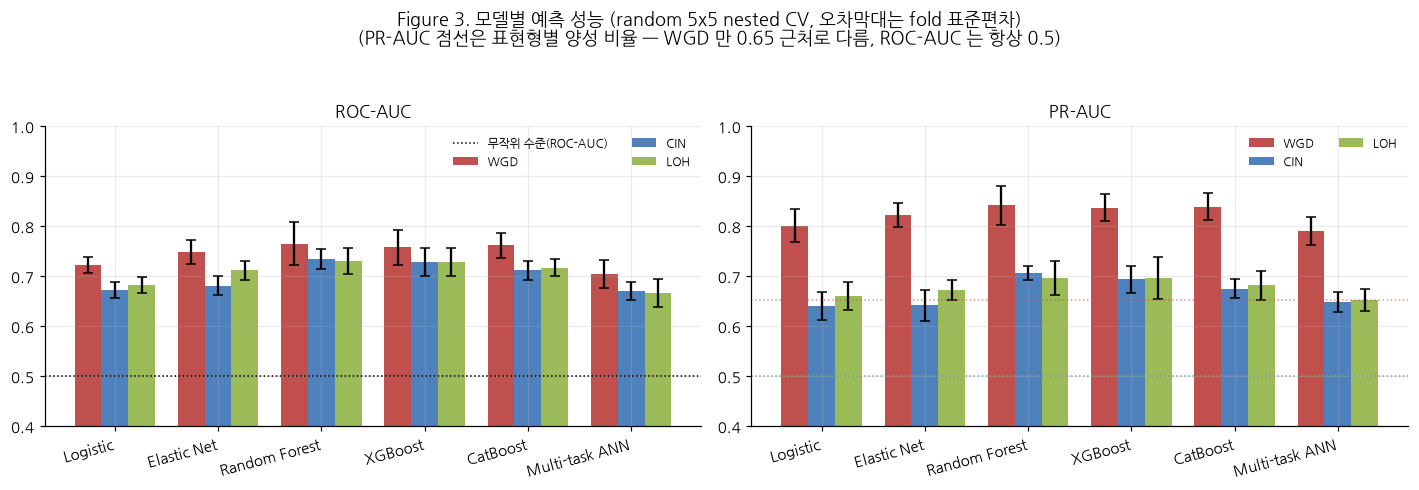

In [4]:
# Figure 3 — scripts/06_compare_models.py 의 plot_comparison() 을 그대로 옮긴 것.
MODEL_ORDER = ["logistic", "elastic_net", "random_forest", "xgboost", "catboost", "multitask_ann"]
MODEL_LABEL = {"logistic": "Logistic", "elastic_net": "Elastic Net",
               "random_forest": "Random Forest", "xgboost": "XGBoost",
               "catboost": "CatBoost", "multitask_ann": "Multi-task ANN"}

# cv_random_{model}_{target}.csv 만 정확히 읽는다 — glob 으로 긁으면
# cv_random_random_forest_damaging_only_wgd.csv(보조 파일)까지 섞여 WGD/RF 행이 오염된다.
frames = [pd.read_csv(TABLES / f"cv_random_{m}_{t}.csv")
          for m in MODEL_ORDER for t in TARGETS
          if (TABLES / f"cv_random_{m}_{t}.csv").exists()]
cv = pd.concat(frames, ignore_index=True)

# PR-AUC 의 무작위 기준선은 0.5 가 아니라 표현형별 양성 비율이다.
prevalence = {"wgd": float(cohort_y.wgd.mean())}
for t in ("cin", "loh"):
    prevalence[t] = float((cohort_y[t] >= cohort_y[t].median()).mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
models = [m for m in MODEL_ORDER if m in set(cv.model)]
width, x = 0.26, np.arange(len(models))

for ax, metric, title in ((axes[0], "roc_auc", "ROC-AUC"), (axes[1], "pr_auc", "PR-AUC")):
    for i, target in enumerate(TARGETS):
        sub = cv[cv.target == target]
        means = [sub[sub.model == m][metric].mean() for m in models]
        errs = [sub[sub.model == m][metric].std() for m in models]
        ax.bar(x + (i - 1) * width, means, width, yerr=errs, capsize=3,
               label=TARGET_LABEL[target], color=PHENOTYPE_COLORS[target])
    if metric == "roc_auc":
        ax.axhline(0.5, color="k", ls=":", lw=1, label="무작위 수준(ROC-AUC)")
    else:
        for target in TARGETS:
            ax.axhline(prevalence[target], color=PHENOTYPE_COLORS[target], ls=":", lw=1, alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABEL[m] for m in models], rotation=15, ha="right")
    ax.set_title(title)
    ax.set_ylim(0.4, 1.0)
    ax.legend(fontsize=8, ncol=2)

fig.suptitle("Figure 3. 모델별 예측 성능 (random 5x5 nested CV, 오차막대는 fold 표준편차)\n"
             "(PR-AUC 점선은 표현형별 양성 비율 — WGD 만 0.65 근처로 다름, ROC-AUC 는 항상 0.5)",
             y=1.05, fontsize=12)
fig.tight_layout()
plt.show()

## 3. Random Forest Confusion Matrix

5개 outer fold의 test 예측을 pooled 한 confusion matrix.

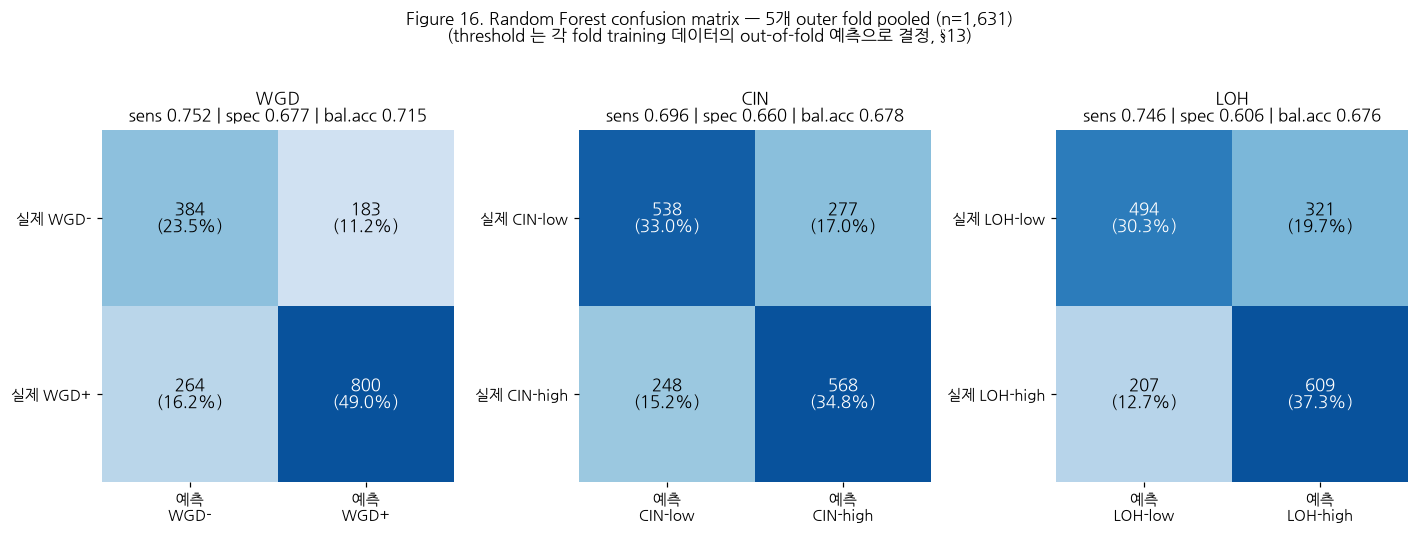

In [5]:
# Figure 16 — scripts/34_plot_rf_confusion_matrix.py 를 그대로 옮긴 것.
CLASS_LABEL = {"wgd": ("WGD-", "WGD+"), "cin": ("CIN-low", "CIN-high"),
               "loh": ("LOH-low", "LOH-high")}
cm_df = pd.read_csv(TABLES / "day33_rf_confusion_matrix.csv").set_index("target")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, target in zip(axes, TARGETS):
    row = cm_df.loc[target]
    cm = np.array([[row.tn, row.fp], [row.fn, row.tp]])
    cm_pct = cm / cm.sum() * 100
    ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=cm_pct.max() * 1.15)
    labels = CLASS_LABEL[target]
    for i in range(2):
        for j in range(2):
            color = "white" if cm_pct[i, j] > cm_pct.max() * 0.6 else "black"
            ax.text(j, i, f"{int(cm[i, j])}\n({cm_pct[i, j]:.1f}%)",
                    ha="center", va="center", fontsize=11, color=color)
    ax.set_xticks([0, 1]); ax.set_xticklabels([f"예측\n{labels[0]}", f"예측\n{labels[1]}"])
    ax.set_yticks([0, 1]); ax.set_yticklabels([f"실제 {labels[0]}", f"실제 {labels[1]}"])
    ax.set_title(f"{TARGET_LABEL[target]}\nsens {row.sensitivity:.3f} | "
                 f"spec {row.specificity:.3f} | bal.acc {row.balanced_accuracy:.3f}")
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)

fig.suptitle("Figure 16. Random Forest confusion matrix — 5개 outer fold pooled (n=1,631)\n"
             "(threshold 는 각 fold training 데이터의 out-of-fold 예측으로 결정, §13)",
             y=1.06, fontsize=11)
fig.tight_layout()
plt.show()

## 4. Feature Importance — 어떤 mutation이 중요한가

각 outer fold의 training data에서 feature selection을 반복해, 5개 fold
전부에서 선택된("전 fold 공통") 유전자를 찾는다(Random Forest 기준).

In [6]:
for target in ("wgd", "cin", "loh"):
    df = pd.read_csv(TABLES / f"day11_selection_random_forest_{target}.csv")
    common = df[df.selection_freq == 1.0]
    genes = ", ".join(common.gene.head(8))
    print(f"{target.upper()}: 전 fold(5/5) 공통 {len(common)}개 — {genes}")

WGD: 전 fold(5/5) 공통 19개 — TP53, TP53, TERT, BRAF, ID3, LRP1B, TTN, KRAS
CIN: 전 fold(5/5) 공통 21개 — TP53, TP53, TERT, RB1, ID3, BRAF, PIK3CA, KRAS
LOH: 전 fold(5/5) 공통 18개 — TP53, TP53, RB1, ID3, KRAS, NF2, ARID1A, PITX1


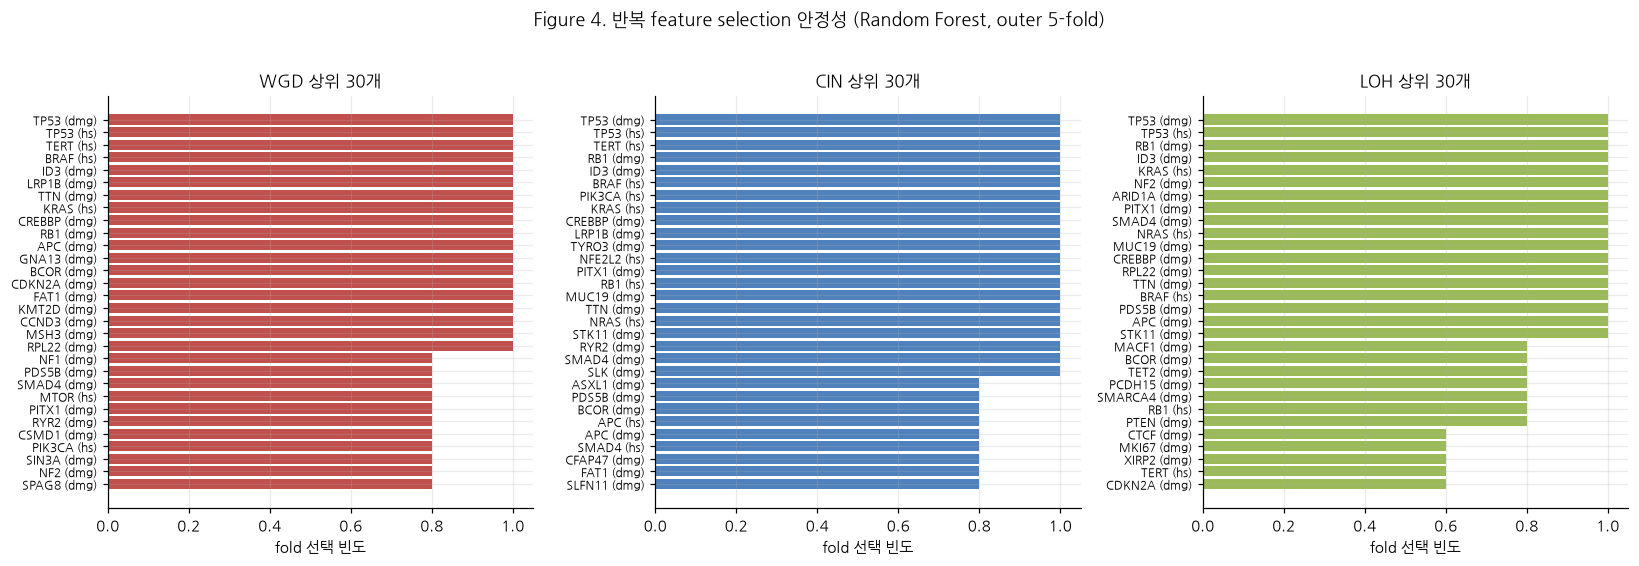

In [7]:
# Figure 4 — scripts/07_aggregate_selection.py 의 plot_stability() 를 그대로 옮긴 것.
# day11_selection_*.csv 가 이미 fold 집계 결과(selection_freq 포함)다.
TOP_N = 30


def short(feature: str, width: int = 22) -> str:
    """'TP53 (7157)_damaging' -> 'TP53 (dmg)'"""
    gene = feature.split(" (")[0]
    kind = "hs" if feature.endswith("_hotspot") else "dmg"
    return f"{gene} ({kind})"[:width]


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, target in zip(axes, TARGETS):
    agg = pd.read_csv(TABLES / f"day11_selection_random_forest_{target}.csv")
    top = agg.head(TOP_N).iloc[::-1]
    ax.barh([short(f) for f in top.feature], top.selection_freq, color=PHENOTYPE_COLORS[target])
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("fold 선택 빈도")
    ax.set_title(f"{TARGET_LABEL[target]} 상위 {TOP_N}개")
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("Figure 4. 반복 feature selection 안정성 (Random Forest, outer 5-fold)",
             y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

**TP53이 세 표현형 모두에서 압도적 1위**(평균 순위 1.0, 순위 표준편차 0)다.
ID3·BRAF·CREBBP도 세 표현형 공통 후보로 반복 선택된다.

## 5. 최소 Mutation Panel

10개 mutation으로 전체 성능의 93\~99%가 유지된다.

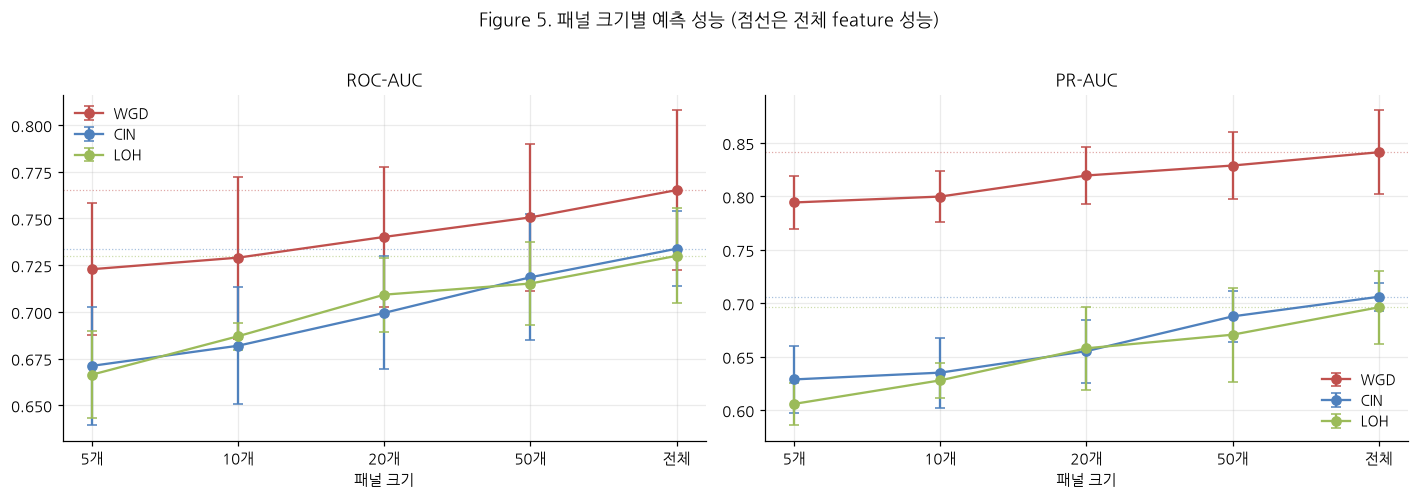

In [8]:
# Figure 5 — scripts/08_panel_curve.py 의 plot_curve() 를 그대로 옮긴 것.
metrics = pd.read_csv(TABLES / "day12_panel_metrics_random_forest.csv")
metrics["panel_size"] = metrics["panel_size"].astype(str)
sizes = sorted({int(s) for s in metrics.panel_size.unique() if s != "all"})
order = [str(s) for s in sizes] + ["all"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, metric, title in ((axes[0], "roc_auc", "ROC-AUC"), (axes[1], "pr_auc", "PR-AUC")):
    for target in TARGETS:
        sub = metrics[metrics.target == target]
        g = sub.groupby("panel_size")[metric]
        mean, std = g.mean().reindex(order), g.std().reindex(order)
        ax.errorbar(range(len(order)), mean, yerr=std, marker="o", capsize=3,
                    label=TARGET_LABEL[target], color=PHENOTYPE_COLORS[target])
        full = mean.get("all")
        if pd.notna(full):
            ax.axhline(full, color=PHENOTYPE_COLORS[target], ls=":", lw=0.8, alpha=0.5)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f"{o}개" if o != "all" else "전체" for o in order])
    ax.set_xlabel("패널 크기")
    ax.set_title(title)
    ax.legend(fontsize=9)

fig.suptitle("Figure 5. 패널 크기별 예측 성능 (점선은 전체 feature 성능)", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

## 6. 후속 실험 — Pathway(음성) vs Signature(양성) vs 결합(항상 개선)

Pathway 재집계 — 6/6 조합 전부 하락 (음성)


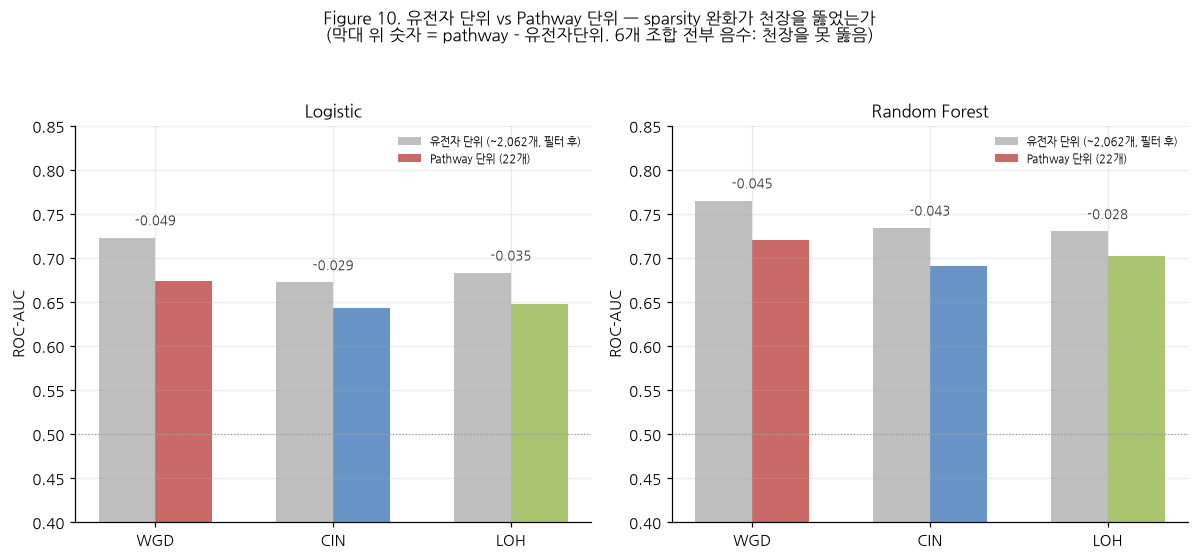

target         model  gene_level_auc  pathway_auc     차이
   wgd      logistic           0.723        0.674 -0.049
   cin      logistic           0.672        0.643 -0.029
   loh      logistic           0.683        0.648 -0.035
   wgd random_forest           0.765        0.720 -0.045
   cin random_forest           0.734        0.691 -0.043
   loh random_forest           0.730        0.702 -0.028
Mutation signature(96-class) — 5/6 조합 개선 (양성)


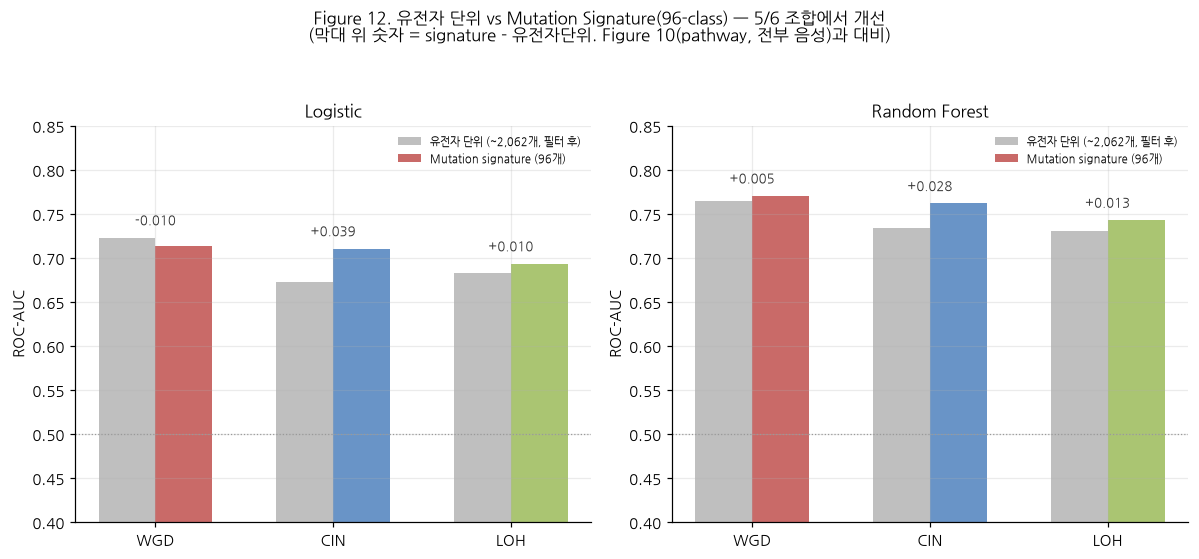

target         model  gene_level_auc  signature_auc     차이
   wgd      logistic           0.723          0.713 -0.010
   cin      logistic           0.672          0.711  0.039
   loh      logistic           0.683          0.693  0.010
   wgd random_forest           0.765          0.770  0.005
   cin random_forest           0.734          0.762  0.028
   loh random_forest           0.730          0.743  0.013
유전자+Signature 결합 — 6/6 조합 전부 개선


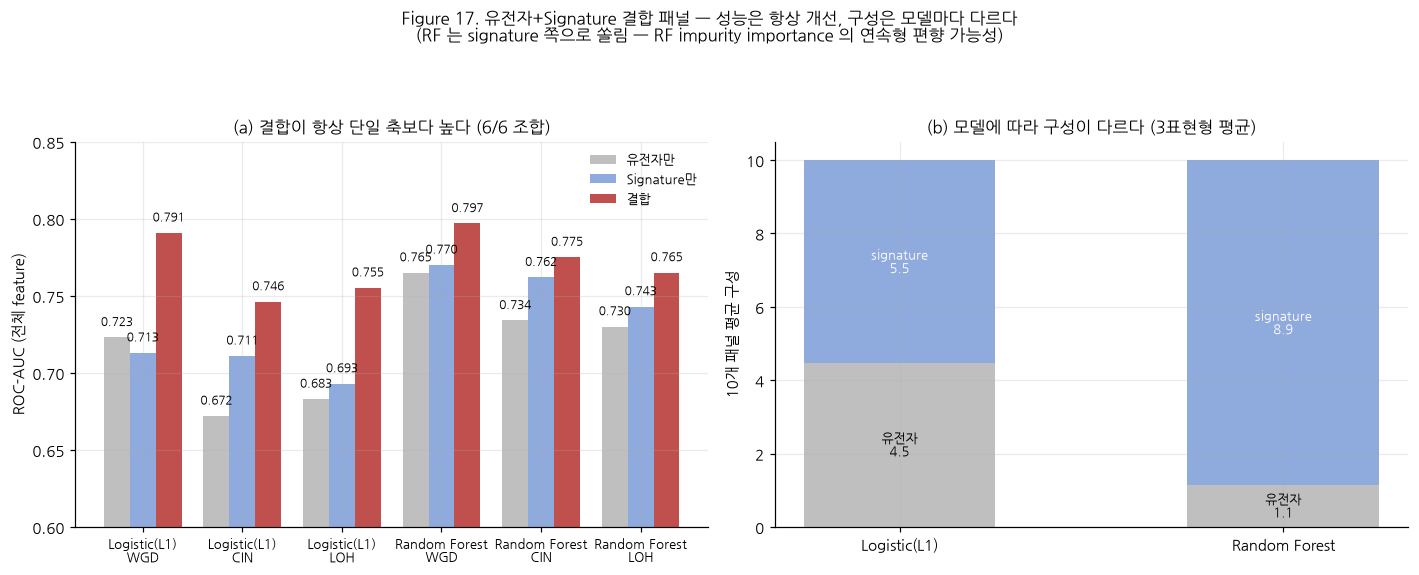

In [9]:
print("Pathway 재집계 — 6/6 조합 전부 하락 (음성)")
# Figure 10 — scripts 의 해당 plot 스크립트를 그대로 옮긴 것.
df = pd.read_csv(TABLES / "day19_pathway_vs_gene.csv")
models = ["logistic", "random_forest"]
MODEL_LABEL2 = {"logistic": "Logistic", "random_forest": "Random Forest"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, model in zip(axes, models):
    sub = df[df.model == model].set_index("target").reindex(list(TARGETS))
    x, width = np.arange(3), 0.32
    ax.bar(x - width / 2, sub.gene_level_auc, width,
           label="유전자 단위 (~2,062개, 필터 후)", color="#bfbfbf")
    ax.bar(x + width / 2, sub.pathway_auc, width,
           label="Pathway 단위 (22개)", color=[PHENOTYPE_COLORS[t] for t in TARGETS], alpha=0.85)
    for i, (gene_auc, other) in enumerate(zip(sub.gene_level_auc, sub.pathway_auc)):
        ax.text(i, max(gene_auc, other) + 0.015, f"{other - gene_auc:+.3f}",
                ha="center", fontsize=8.5, color="#333")
    ax.axhline(0.5, color="#999", ls=":", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([TARGET_LABEL[t] for t in TARGETS])
    ax.set_ylim(0.4, 0.85)
    ax.set_ylabel("ROC-AUC")
    ax.set_title(MODEL_LABEL2[model])
    ax.legend(fontsize=7.5, loc="upper right")

fig.suptitle("Figure 10. 유전자 단위 vs Pathway 단위 — sparsity 완화가 천장을 뚫었는가\n"
             "(막대 위 숫자 = pathway - 유전자단위. 6개 조합 전부 음수: 천장을 못 뚫음)", y=1.05, fontsize=11)
fig.tight_layout()
plt.show()
print(df.round(3).to_string(index=False))

print("Mutation signature(96-class) — 5/6 조합 개선 (양성)")
# Figure 12 — scripts 의 해당 plot 스크립트를 그대로 옮긴 것.
df = pd.read_csv(TABLES / "day24_signature_vs_gene.csv")
models = ["logistic", "random_forest"]
MODEL_LABEL2 = {"logistic": "Logistic", "random_forest": "Random Forest"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, model in zip(axes, models):
    sub = df[df.model == model].set_index("target").reindex(list(TARGETS))
    x, width = np.arange(3), 0.32
    ax.bar(x - width / 2, sub.gene_level_auc, width,
           label="유전자 단위 (~2,062개, 필터 후)", color="#bfbfbf")
    ax.bar(x + width / 2, sub.signature_auc, width,
           label="Mutation signature (96개)", color=[PHENOTYPE_COLORS[t] for t in TARGETS], alpha=0.85)
    for i, (gene_auc, other) in enumerate(zip(sub.gene_level_auc, sub.signature_auc)):
        ax.text(i, max(gene_auc, other) + 0.015, f"{other - gene_auc:+.3f}",
                ha="center", fontsize=8.5, color="#333")
    ax.axhline(0.5, color="#999", ls=":", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([TARGET_LABEL[t] for t in TARGETS])
    ax.set_ylim(0.4, 0.85)
    ax.set_ylabel("ROC-AUC")
    ax.set_title(MODEL_LABEL2[model])
    ax.legend(fontsize=7.5, loc="upper right")

fig.suptitle("Figure 12. 유전자 단위 vs Mutation Signature(96-class) — 5/6 조합에서 개선\n"
             "(막대 위 숫자 = signature - 유전자단위. Figure 10(pathway, 전부 음성)과 대비)", y=1.05, fontsize=11)
fig.tight_layout()
plt.show()
print(df.round(3).to_string(index=False))

print("유전자+Signature 결합 — 6/6 조합 전부 개선")
# Figure 17 — scripts/35_plot_combined_panel.py 를 그대로 옮긴 것.
summary = pd.read_csv(TABLES / "day32_combined_vs_single_summary.csv")
comp = pd.read_csv(TABLES / "day32_combined_panel_composition.csv")
CMODELS = ("logistic_l1", "random_forest")
CMODEL_LABEL = {"logistic_l1": "Logistic(L1)", "random_forest": "Random Forest"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
combos = [(m, t) for m in CMODELS for t in TARGETS]
x, width = np.arange(len(combos)), 0.26
pick = lambda col: [summary[(summary.model == m) & (summary.target == t)][col].iloc[0]
                    for m, t in combos]
gene_v, sig_v, combined_v = pick("유전자만"), pick("signature만"), pick("결합")

ax.bar(x - width, gene_v, width, label="유전자만", color="#bfbfbf")
ax.bar(x, sig_v, width, label="Signature만", color="#8faadc")
ax.bar(x + width, combined_v, width, label="결합", color="#c0504d")
for i, v in enumerate(gene_v):
    ax.text(i - width, v + 0.008, f"{v:.3f}", ha="center", fontsize=8)
for i, v in enumerate(sig_v):
    ax.text(i, v + 0.008, f"{v:.3f}", ha="center", fontsize=8)
for i, v in enumerate(combined_v):
    ax.text(i + width, v + 0.008, f"{v:.3f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f"{CMODEL_LABEL[m]}\n{TARGET_LABEL[t]}" for m, t in combos], fontsize=8.5)
ax.set_ylabel("ROC-AUC (전체 feature)")
ax.set_ylim(0.6, 0.85)
ax.set_title("(a) 결합이 항상 단일 축보다 높다 (6/6 조합)")
ax.legend(fontsize=8.5)

ax2 = axes[1]
comp10 = comp[comp.panel_size == 10].groupby("model")[["n_genes", "n_sig"]].mean().reindex(CMODELS)
xm = np.arange(len(CMODELS))
ax2.bar(xm, comp10.n_genes, 0.5, label="유전자", color="#bfbfbf")
ax2.bar(xm, comp10.n_sig, 0.5, bottom=comp10.n_genes, label="Signature class", color="#8faadc")
for i, (g, s) in enumerate(zip(comp10.n_genes, comp10.n_sig)):
    ax2.text(i, g / 2, f"유전자\n{g:.1f}", ha="center", va="center", fontsize=8.5)
    ax2.text(i, g + s / 2, f"signature\n{s:.1f}", ha="center", va="center", fontsize=8.5, color="white")
ax2.set_xticks(list(xm))
ax2.set_xticklabels([CMODEL_LABEL[m] for m in CMODELS])
ax2.set_ylabel("10개 패널 평균 구성")
ax2.set_title("(b) 모델에 따라 구성이 다르다 (3표현형 평균)")

fig.suptitle("Figure 17. 유전자+Signature 결합 패널 — 성능은 항상 개선, 구성은 모델마다 다르다\n"
             "(RF 는 signature 쪽으로 쏠림 — RF impurity importance 의 연속형 편향 가능성)",
             y=1.08, fontsize=11)
fig.tight_layout()
plt.show()

## 7. TCGA 외부 코호트 검증

세포주가 아닌 실제 환자 종양(TCGA)에서 WGD를 검증 — 내부 0.762 → 외부 0.594
(방법론적 한계로 인한 하한 추정치, 상세는 전체 노트북 §13 참고).

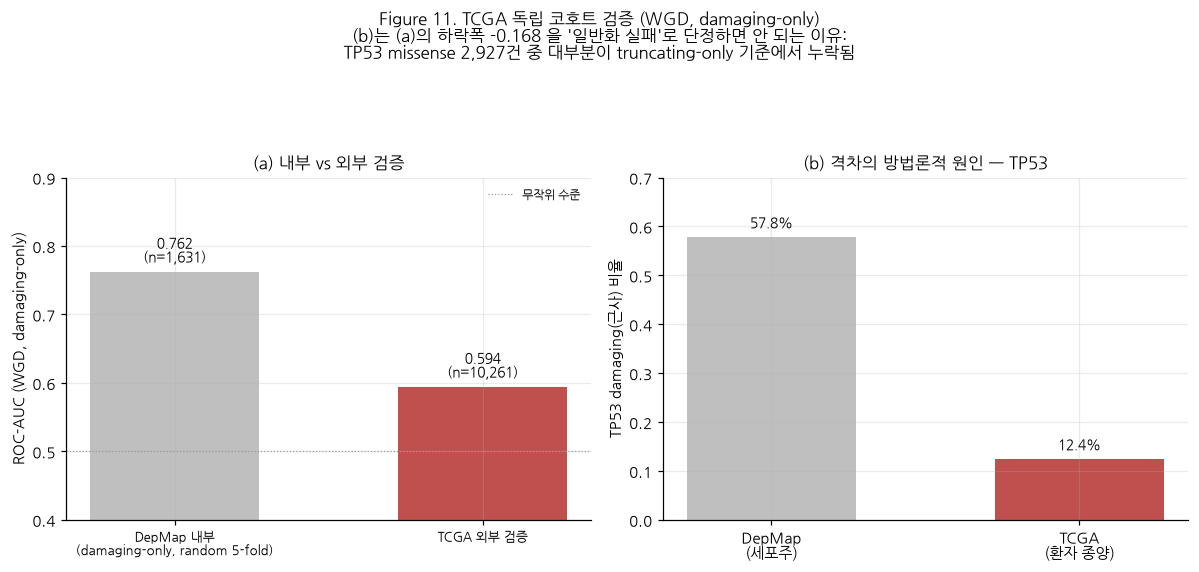

                                  stage  roc_auc     n
DepMap 내부(damaging-only, random 5-fold) 0.762229  1631
                             TCGA 외부 검증 0.594063 10261


In [10]:
# Figure 11 — scripts/22_plot_tcga_validation.py 를 그대로 옮긴 것.
tcga = pd.read_csv(TABLES / "day21_tcga_validation_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
ax = axes[0]
bars = ax.bar(tcga.stage.str.replace("(", "\n(", regex=False), tcga.roc_auc,
              color=["#bfbfbf", PHENOTYPE_COLORS["wgd"]], width=0.55)
for b, v, n in zip(bars, tcga.roc_auc, tcga.n):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.3f}\n(n={n:,})",
            ha="center", fontsize=9)
ax.axhline(0.5, color="#999", ls=":", lw=0.8, label="무작위 수준")
ax.set_ylim(0.4, 0.9)
ax.set_ylabel("ROC-AUC (WGD, damaging-only)")
ax.set_title("(a) 내부 vs 외부 검증")
ax.legend(fontsize=8)
ax.tick_params(axis="x", labelsize=8.5)

ax = axes[1]
tp53 = pd.DataFrame({"cohort": ["DepMap\n(세포주)", "TCGA\n(환자 종양)"], "rate": [0.578, 0.124]})
ax.bar(tp53.cohort, tp53.rate, color=["#bfbfbf", PHENOTYPE_COLORS["wgd"]], width=0.55)
for i, v in enumerate(tp53.rate):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=9)
ax.set_ylim(0, 0.7)
ax.set_ylabel("TP53 damaging(근사) 비율")
ax.set_title("(b) 격차의 방법론적 원인 — TP53")

fig.suptitle("Figure 11. TCGA 독립 코호트 검증 (WGD, damaging-only)\n"
             "(b)는 (a)의 하락폭 -0.168 을 '일반화 실패'로 단정하면 안 되는 이유:\n"
             "TP53 missense 2,927건 중 대부분이 truncating-only 기준에서 누락됨",
             y=1.12, fontsize=11)
fig.tight_layout()
plt.show()
print(tcga.to_string(index=False))

## 8. 최종 후보 Biomarker Panel (8개 유전자)

fold 반복·모델 간 합의·회귀 재검증·TCGA 방향성 지지를 종합한 최종 후보.

In [11]:
panel = pd.DataFrame([
    ("TP53", "damaging+hotspot", "WGD/CIN/LOH 공통", "세 표현형 전부 평균 순위 1위"),
    ("ID3", "damaging", "WGD/CIN/LOH 공통", ""),
    ("BRAF", "hotspot", "WGD/CIN/LOH 공통", ""),
    ("CREBBP", "damaging", "WGD/CIN/LOH 공통", ""),
    ("TERT", "hotspot", "WGD 특이", "telomerase 역전사효소"),
    ("RB1", "damaging", "CIN 특이", "G1/S checkpoint tumor suppressor"),
    ("PIK3CA", "hotspot", "CIN 특이", "PI3K 촉매 subunit"),
    ("PITX1", "damaging", "LOH 특이", "발생 전사인자"),
], columns=["gene", "type", "role", "note"])
panel

,gene,type,role,note
0,TP53,damaging+hotspot,WGD/CIN/LOH 공통,세 표현형 전부 평균 순위 1위
1,ID3,damaging,WGD/CIN/LOH 공통,
2,BRAF,hotspot,WGD/CIN/LOH 공통,
3,CREBBP,damaging,WGD/CIN/LOH 공통,
4,TERT,hotspot,WGD 특이,telomerase 역전사효소
5,RB1,damaging,CIN 특이,G1/S checkpoint tumor suppressor
6,PIK3CA,hotspot,CIN 특이,PI3K 촉매 subunit
7,PITX1,damaging,LOH 특이,발생 전사인자


## 9. 결론

- ROC-AUC 0.73\~0.77 수준으로 mutation만으로 유전체 불안정성 예측 가능
  (acceptable 구간, 임상 확정 바이오마커는 아님)
- Random Forest 1위, 핵심 신호는 TP53 중심 소수 유전자에 집중
- lineage(암종) 일반화는 제한적 — 원인 미규명
- Pathway(음성)와 Signature(양성)가 정반대로 갈려, "유전자 정체성"과
  "변이 발생 과정"이 상보적인 정보임을 확인
- TCGA 외부 검증은 방향은 유지되나 방법론적 하한 추정치

상세: `docs/research/2026-08-16/final_conclusion.md`,
`docs/research/2026-08-19/biomarker_panel.md`.